In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Memory ablation plots (from CSV logs, no inference)
ABLATION_ROOT = Path("/home/mengnan/seg3d/src/seg3d/ablation_studies/memory_ablation")
LOG_DIR = ABLATION_ROOT / "logging"
FIG_DIR = ABLATION_ROOT / "figures"

summary_csv = LOG_DIR / "ablation_memory_summary.csv"
per_view_csv = LOG_DIR / "ablation_memory_per_view.csv"

df_summary = pd.read_csv(summary_csv)
df_summary = df_summary.sort_values("Mean IoU", ascending=False)
df_summary

,Model,Mean IoU,Std IoU,Mean Dice,Std Dice,Num Meshes
0,Dual (Normal+Point) + Geo-aware mem,57.165936,16.762238,62.358924,16.287070,40
1,Dual (Normal+Point) + Orig mem,56.738176,16.719956,61.951520,16.246055,40
2,Geo-aware mem + Point,52.497210,18.619123,58.058263,18.833746,40
3,Orig mem + Point,51.855430,18.570414,57.454528,18.764782,40
4,Geo-aware mem + Matte,50.865627,18.363988,55.748822,18.323239,40
5,Geo-aware mem + Normal,49.645388,19.283669,54.375255,19.352666,40
6,Orig mem + Matte,49.158688,18.439863,54.039758,18.409898,40
7,Orig mem + Normal,48.042518,19.188181,52.715734,19.373029,40


Saved /home/mengnan/seg3d/src/seg3d/ablation_studies/memory_ablation/figures/ablation_memory_metrics.png


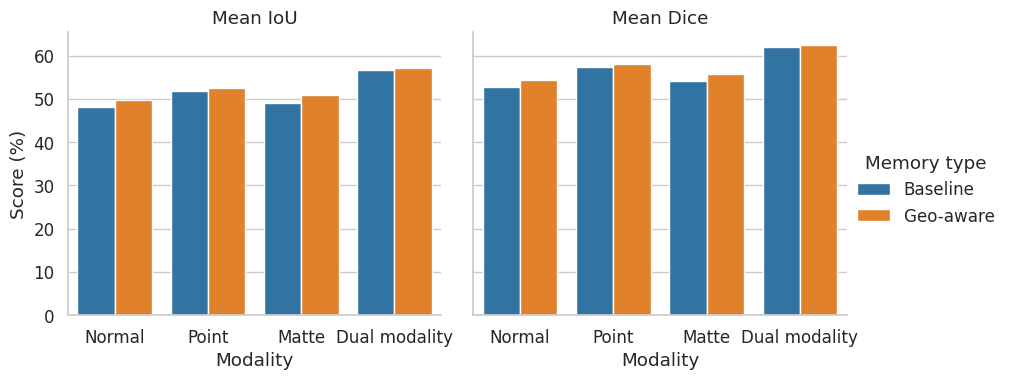

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Seaborn-style bar plot (matches ablation_memory.ipynb style), including Dual models
palette = {
    "Original": "#1f77b4",   # classic matplotlib blue
    "Geo-aware": "#ff7f0e", # classic matplotlib orange
}

def _row_to_groups(model_name: str):
    if model_name.startswith("Orig mem + "):
        memory = "Original"
        modality = model_name.split("+")[-1].strip()  # Normal / Point / Matte
    elif model_name.startswith("Geo-aware mem + "):
        memory = "Geo-aware"
        modality = model_name.split("+")[-1].strip()  # Normal / Point / Matte
    elif model_name.startswith("Dual "):
        modality = "Dual"
        memory = "Original" if " + Orig mem" in model_name else "Geo-aware"
    else:
        # fallback
        modality = "Other"
        memory = "Geo-aware" if "Geo-aware" in model_name else "Original"
    return memory, modality

records = []
for _, r in df_summary.iterrows():
    mem, mod = _row_to_groups(str(r["Model"]))
    records.append(
        {
            "Memory": mem,
            "Modality": mod,
            "Mean IoU": float(r["Mean IoU"]),
            "Mean Dice": float(r["Mean Dice"]),
        }
    )

df = pd.DataFrame(records)
df_long = df.melt(
    id_vars=["Memory", "Modality"],
    value_vars=["Mean IoU", "Mean Dice"],
    var_name="Metric",
    value_name="Score (%)",
)

sns.set(style="whitegrid", font_scale=1.1)

order = ["Normal", "Point", "Matte", "Dual"]

g = sns.catplot(
    data=df_long,
    kind="bar",
    x="Modality",
    y="Score (%)",
    hue="Memory",
    col="Metric",
    order=order,
    hue_order=["Original", "Geo-aware"],
    col_order=["Mean IoU", "Mean Dice"],
    palette=palette,
    dodge=True,
    height=4,
    aspect=1.1,
)

g.set_axis_labels("Modality", "Score (%)")
g.set_titles("{col_name}")

g._legend.set_title("Memory type")
plt.subplots_adjust(top=0.8)
g.fig.suptitle("Original vs Geo-aware Memory Across Modalities (incl. Dual)")

FIG_DIR.mkdir(parents=True, exist_ok=True)
out_path = FIG_DIR / "ablation_memory_metrics.png"
g.fig.savefig(out_path, dpi=150, bbox_inches="tight")
print("Saved", out_path)

plt.show()


Saved /home/mengnan/seg3d/src/seg3d/ablation_studies/memory_ablation/figures/ablation_memory_per_view_iou.png


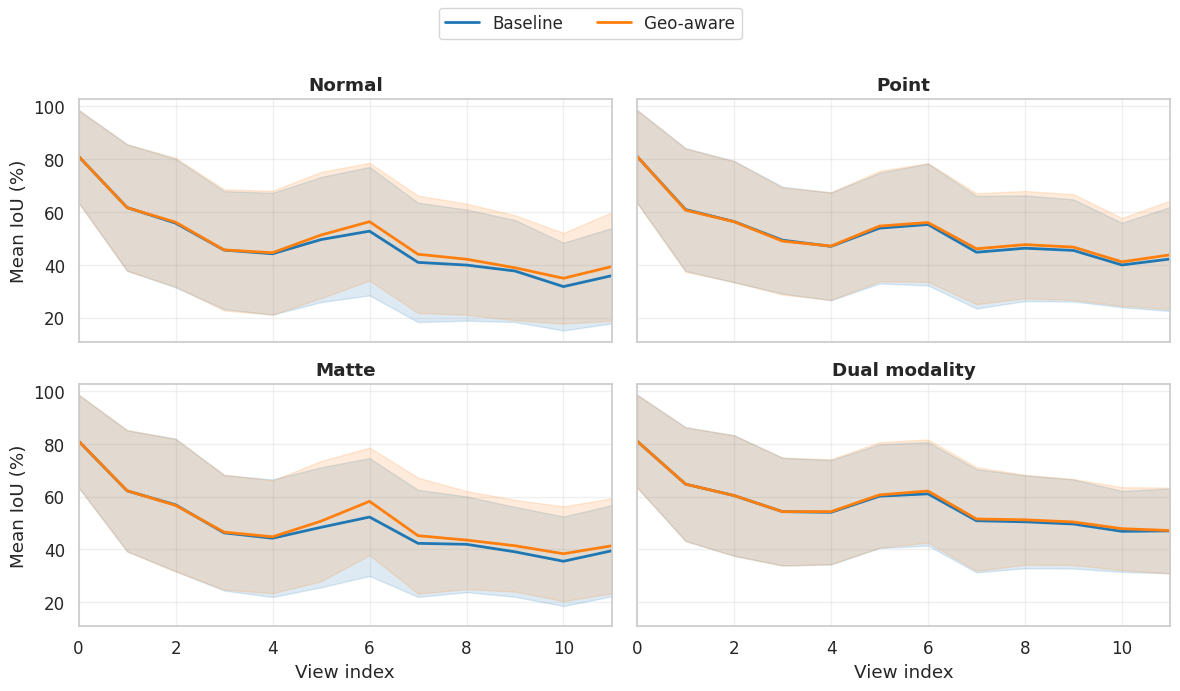

In [13]:
# Per-view IoU curves (2x2): compare Baseline vs Geo-aware per modality/setting
import numpy as np


df_pv = pd.read_csv(per_view_csv)

palette = {
    "Baseline": "#1f77b4",   # blue
    "Geo-aware": "#ff7f0e",  # orange
}

# Map each subplot to its two model names in the CSV
pairs = {
    "Normal": {
        "Baseline": "Orig mem + Normal",
        "Geo-aware": "Geo-aware mem + Normal",
    },
    "Point": {
        "Baseline": "Orig mem + Point",
        "Geo-aware": "Geo-aware mem + Point",
    },
    "Matte": {
        "Baseline": "Orig mem + Matte",
        "Geo-aware": "Geo-aware mem + Matte",
    },
    "Dual modality": {
        "Baseline": "Dual (Normal+Point) + Orig mem",
        "Geo-aware": "Dual (Normal+Point) + Geo-aware mem",
    },
}

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (title, model_map) in zip(axes, pairs.items()):
    for mem_type in ["Baseline", "Geo-aware"]:
        model_name = model_map[mem_type]
        d = df_pv[df_pv["Model"] == model_name].sort_values("View")
        if d.empty:
            continue
        color = palette[mem_type]
        ax.plot(
            d["View"].values,
            d["Mean IoU"].values,
            label=mem_type,
            linewidth=2,
            color=color,
        )
        # light std shading for readability
        ax.fill_between(
            d["View"].values,
            d["Mean IoU"].values - d["Std IoU"].values,
            d["Mean IoU"].values + d["Std IoU"].values,
            alpha=0.15,
            color=color,
        )

    ax.set_title(title, fontweight="bold")
    ax.grid(alpha=0.3)

# Shared labels
for ax in axes[2:]:
    ax.set_xlabel("View index")
for ax in (axes[0], axes[2]):
    ax.set_ylabel("Mean IoU (%)")

# One legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=True)

# x limits
if not df_pv.empty:
    for ax in axes:
        ax.set_xlim(0, int(df_pv["View"].max()))

plt.tight_layout(rect=(0, 0, 1, 0.92))
out_pv = FIG_DIR / "ablation_memory_per_view_iou.png"
plt.savefig(out_pv, dpi=150, bbox_inches="tight")
print("Saved", out_pv)
plt.show()
plt.close(fig)


Saved /home/mengnan/seg3d/src/seg3d/ablation_studies/modality_ablation/figures/ablation_modality_metrics.png


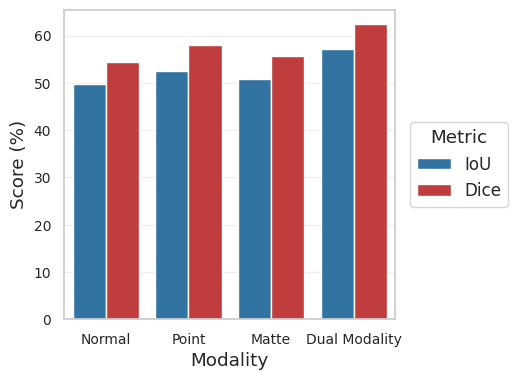

In [25]:
# Modality ablation bar plot: one figure, IoU & Dice as two colored bars per modality
from pathlib import Path

MOD_ROOT = Path("/home/mengnan/seg3d/src/seg3d/ablation_studies/modality_ablation")
MOD_LOG_DIR = MOD_ROOT / "logging"
MOD_FIG_DIR = MOD_ROOT / "figures"
mod_summary_csv = MOD_LOG_DIR / "ablation_modality_summary.csv"

mod_df_summary = pd.read_csv(mod_summary_csv)  # values already in percent

# Map model names to modality labels used on x-axis
#  - Geo-aware mem + Normal -> Normal
#  - Geo-aware mem + Point  -> Point
#  - Geo-aware mem + Matte  -> Matte
#  - Finetuned Multimodal (MM + Geo-aware mem) -> Dual

def _modality_label(model_name: str) -> str:
    if model_name.startswith("Geo-aware mem + "):
        return model_name.split("+")[-1].strip()  # Normal / Point / Matte
    if model_name.startswith("Finetuned Multimodal"):
        return "Dual Modality"
    return "Other"

records_mod = []
for _, r in mod_df_summary.iterrows():
    mod = _modality_label(str(r["Model"]))
    records_mod.append(
        {
            "Modality": mod,
            "Mean IoU": float(r["Mean IoU"]),
            "Mean Dice": float(r["Mean Dice"]),
        }
    )

mod_df = pd.DataFrame(records_mod)
mod_df_long = mod_df.melt(
    id_vars=["Modality"],
    value_vars=["Mean IoU", "Mean Dice"],
    var_name="Metric",
    value_name="Score (%)",
)

sns.set(style="whitegrid", font_scale=1.1)

order = ["Normal", "Point", "Matte", "Dual Modality"]
metric_palette = {
    "Mean IoU": "#1f77b4",   # blue
    "Mean Dice": "#d62728",  # red
}

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=mod_df_long,
    x="Modality",
    y="Score (%)",
    hue="Metric",
    order=order,
    hue_order=["Mean IoU", "Mean Dice"],
    palette=metric_palette,
)

ax.set_xlabel("Modality")
ax.set_ylabel("Score (%)")
#ax.set_title("Modality ablation: IoU & Dice per modality (Geo-aware mem)")
ax.grid(axis="y", alpha=0.3)

# Make tick labels smaller to avoid overlap
ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)

# Move legend outside so it doesn't overlay bars, and shorten labels
a_handles, a_labels = ax.get_legend_handles_labels()
if a_handles:
    ax.legend(
        a_handles,
        ["IoU", "Dice"],
        title="Metric",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True,
    )

plt.tight_layout(rect=(0, 0, 0.9, 1))
MOD_FIG_DIR.mkdir(parents=True, exist_ok=True)
mod_out_path = MOD_FIG_DIR / "ablation_modality_metrics.png"
plt.savefig(mod_out_path, dpi=150, bbox_inches="tight")
print("Saved", mod_out_path)
plt.show()

Found pngs:
 - chair_no_residual.png
 - chair_residual.png
 - lamp_no_residual.png
 - lamp_residual.png


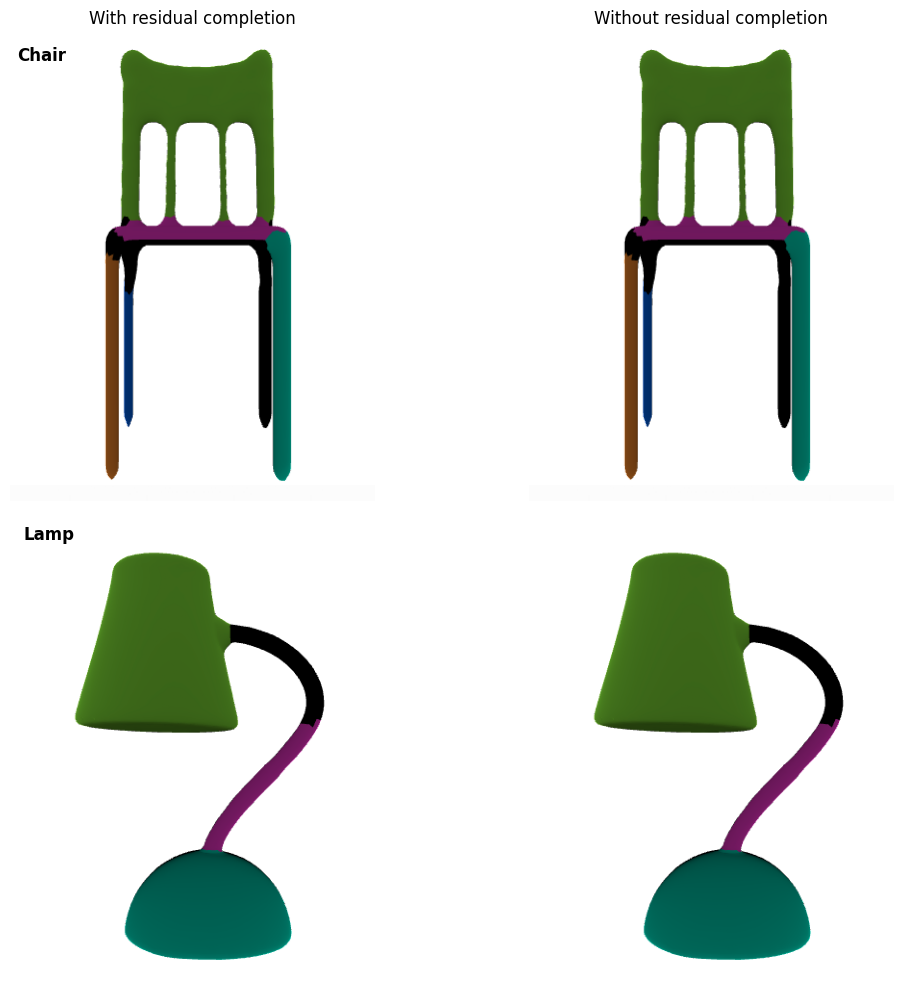

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 1) Set base_dir
try:
    base_dir = Path('/home/mengnan/seg3d/residual_completion_ablation')  # noqa: F821
except NameError:
    base_dir = Path("/home/mengnan/seg3d/PUT_YOUR_RESIDUAL_COMPLETION_PNG_DIR_HERE")
    print("Variable `residual_completion_ablation` not defined.")
    print("Set `base_dir` to your directory containing the 4 pngs, then re-run.")

# 2) Collect pngs
pngs = sorted(base_dir.glob("*.png"))
if not pngs:
    raise FileNotFoundError(f"No .png found in: {base_dir}")

print("Found pngs:")
for p in pngs:
    print(" -", p.name)

def norm(s: str) -> str:
    return s.lower()

def has_any(name: str, keys: list[str]) -> bool:
    n = norm(name)
    return any(k in n for k in keys)

def is_chair(name: str) -> bool:
    return has_any(name, ["chair", "chairs", "chair_"])

def is_lamp(name: str) -> bool:
    return has_any(name, ["lamp", "lamps", "lamp_"])

def is_without(name: str) -> bool:
    return has_any(name, ["without", "disabled", "no_residual", "noresidual", "no-completion", "no_completion"])

def is_with(name: str) -> bool:
    # "with residual completion" sometimes has "enabled" or explicit "residual"
    return has_any(name, ["with", "enabled", "residual", "completion", "residual_completion"])

def pick_png(row_kind: str, col_kind: str):
    # row_kind: "chair" or "lamp"
    # col_kind: "with" or "without"
    candidates = []
    for p in pngs:
        name = p.name
        if row_kind == "chair" and not is_chair(name):
            continue
        if row_kind == "lamp" and not is_lamp(name):
            continue
        if col_kind == "with" and not is_with(name):
            continue
        if col_kind == "without" and not is_without(name):
            continue
        candidates.append(p)

    # If strict match fails, fall back to looser matching
    if not candidates:
        for p in pngs:
            name = p.name
            if row_kind == "chair" and not is_chair(name):
                continue
            if row_kind == "lamp" and not is_lamp(name):
                continue
            candidates.append(p)

    if not candidates:
        raise FileNotFoundError(
            f"Could not find pngs for row={row_kind}, col={col_kind} in {base_dir}.\n"
            f"Available: {[p.name for p in pngs]}"
        )

    return sorted(candidates)[0]

# 3) Plot 2x2 grid: cols=with/without, rows=Chair/Lamp
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

col_titles = ["With residual completion", "Without residual completion"]
row_titles = ["Chair", "Lamp"]

# (row, col) -> (row_kind, col_kind)
cell_map = {
    (0, 0): ("chair", "with"),
    (1, 0): ("lamp", "with"),
    (0, 1): ("chair", "without"),
    (1, 1): ("lamp", "without"),
}

for (r, c), (row_kind, col_kind) in cell_map.items():
    p = pick_png(row_kind, col_kind)
    img = mpimg.imread(p)
    ax = axes[r, c]
    ax.imshow(img)
    ax.axis("off")

    if r == 0:
        ax.set_title(col_titles[c], fontsize=12, pad=10)

    if c == 0:
        ax.text(
            0.02, 0.98, row_titles[r],
            transform=ax.transAxes,
            fontsize=12, fontweight="bold",
            va="top", ha="left",
            color="black",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=3)
        )

plt.tight_layout()
plt.show()

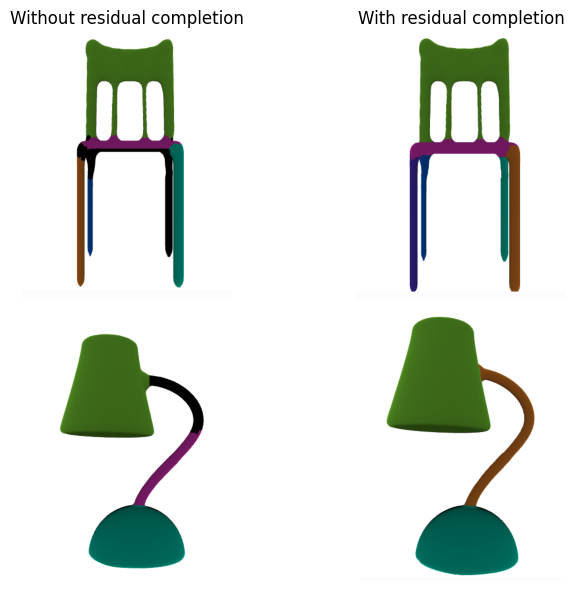

In [9]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

base = Path("/home/mengnan/seg3d/residual_completion_ablation")

img_paths = {
    (0, 0): base / "chair_no_residual.png",
    (0, 1): base / "chair_residual.png",
    (1, 0): base / "lamp_no_residual.png",
    (1, 1): base / "lamp_residual.png",
}

missing = [str(p) for p in img_paths.values() if not p.exists()]
if missing:
    raise FileNotFoundError("Missing files:\n" + "\n".join(missing))

fig, axes = plt.subplots(2, 2, figsize=(8, 6))

# Column titles only (top row)
axes[0, 0].set_title("Without residual completion", fontsize=12)
axes[0, 1].set_title("With residual completion", fontsize=12)

# Optional row labels (Chair / Lamp) on the left
axes[0, 0].set_ylabel("Chair", fontsize=12, rotation=90, labelpad=20)
axes[1, 0].set_ylabel("Lamp", fontsize=12, rotation=90, labelpad=20)

for (r, c), p in img_paths.items():
    ax = axes[r, c]
    ax.imshow(mpimg.imread(p))
    ax.axis("off")

plt.tight_layout()
plt.show()